In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import KFold
import lightgbm as lgbm
from sklearn.metrics import mean_squared_error


In [2]:
train = pd.read_csv('../input/petfinder-pawpularity-score/train.csv')
test = pd.read_csv('../input/petfinder-pawpularity-score/test.csv')


In [3]:
train.head()


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur,Pawpularity
0,1a8795e64a294ed0c95132e18ee198e1,0,1,1,1,0,0,0,0,0,0,0,0,55
1,08ce774252e822838bf598aa10518a11,0,1,1,1,0,0,0,0,0,0,0,0,100
2,a71c677d87606a56160b70c5f6fa4526,0,1,1,0,0,0,0,0,0,0,0,0,27
3,11d5914ad80403375c8e0ccd959fc08e,0,1,1,1,0,0,0,0,0,0,0,0,51
4,c04034bbfe0a0d89729541c2271a674e,0,1,1,1,0,0,0,0,0,0,0,0,48


In [4]:
train_corr = train.corr()
train_corr


ValueError: could not convert string to float: '1a8795e64a294ed0c95132e18ee198e1'

In [5]:
plt.figure(figsize = (13,13))
sns.heatmap(train_corr, vmax=1, vmin=-1, center=0,annot=True)


NameError: name 'train_corr' is not defined

<Figure size 1300x1300 with 0 Axes>

<Axes: ylabel='Frequency'>

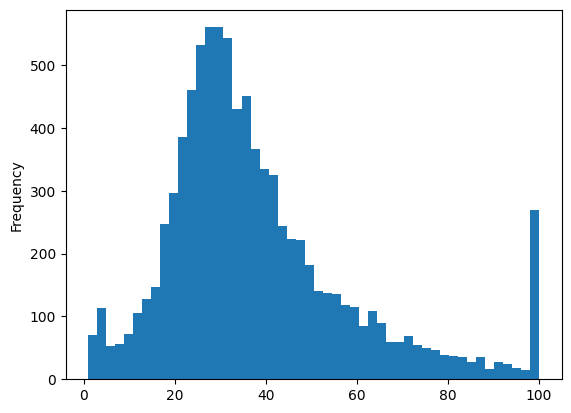

In [6]:
train["Pawpularity"].plot.hist(bins=50)


In [7]:
train["Id"] = train["Id"].astype('category')

X_train = train.drop(['Pawpularity'], axis=1)
Y_train = train['Pawpularity']


In [8]:
kf = KFold(n_splits = 3)
models = []
rmses =[]
categories = ["Id"]

lgbm_params = {
    "random_seed":1234
}

for train_index, val_index in kf.split(X_train):
    XX_train = X_train.iloc[train_index]
    XX_valid = X_train.iloc[val_index]
    YY_train = Y_train.iloc[train_index]
    YY_valid = Y_train.iloc[val_index]
        
    lgbm_train = lgbm.Dataset(XX_train, YY_train, categorical_feature = categories)
    lgbm_eval = lgbm.Dataset(XX_valid, YY_valid, categorical_feature = categories, reference=lgbm_train)
    
    model_lgbm = lgbm.train(lgbm_params,
                           lgbm_train,
                           valid_sets = lgbm_eval,
                           num_boost_round = 100,
                           #early_stopping_rounds = 20,
                           verbose_eval = 10,
                           )
    y_pred = model_lgbm.predict(XX_valid, num_iteration = model_lgbm.best_iteration)
    
    tmp_rmse = np.sqrt(mean_squared_error(YY_valid, y_pred))
    print (tmp_rmse)
    
    models.append(model_lgbm)
    rmses.append(tmp_rmse)


TypeError: train() got an unexpected keyword argument 'verbose_eval'

In [9]:
sum(rmses)/len(rmses)


ZeroDivisionError: division by zero

In [10]:
test.head()


,Id,Subject Focus,Eyes,Face,Near,Action,Accessory,Group,Collage,Human,Occlusion,Info,Blur
0,ee51b99832f1ba868f646df93d2b6b81,0,1,1,1,0,0,0,0,0,0,0,0
1,caddfb3f8bff9c4b95dbe022018eea21,0,0,1,1,0,1,1,0,0,0,0,0
2,582eeabd4a448a53ebb79995888a4b0b,0,1,1,0,0,0,0,0,0,0,0,0
3,afc1ad7f0c5eea880759d09e77f7deee,0,1,1,1,0,0,0,0,0,0,0,0
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,0,1,1,0,0,0,0,1,0,1,1,0


In [11]:
test["Id"] = test["Id"].astype('category')


In [12]:
preds=[]

for model in models:
    pred =model.predict(test)
    preds.append(pred)
    
preds_array = np.array(preds)
preds_mean = np.mean(preds_array, axis=0)


In [13]:
sub = pd.DataFrame()
sub['Id']=test['Id']
sub['Pawpularity'] = preds_mean
sub.to_csv('submission.csv',index=False)
sub.head()


,Id,Pawpularity
0,ee51b99832f1ba868f646df93d2b6b81,NaN
1,caddfb3f8bff9c4b95dbe022018eea21,NaN
2,582eeabd4a448a53ebb79995888a4b0b,NaN
3,afc1ad7f0c5eea880759d09e77f7deee,NaN
4,d5bdf3446e86ce4ec67ce7a00f1cccc2,NaN
